# Research Agent 

Here is our overall research flow: 








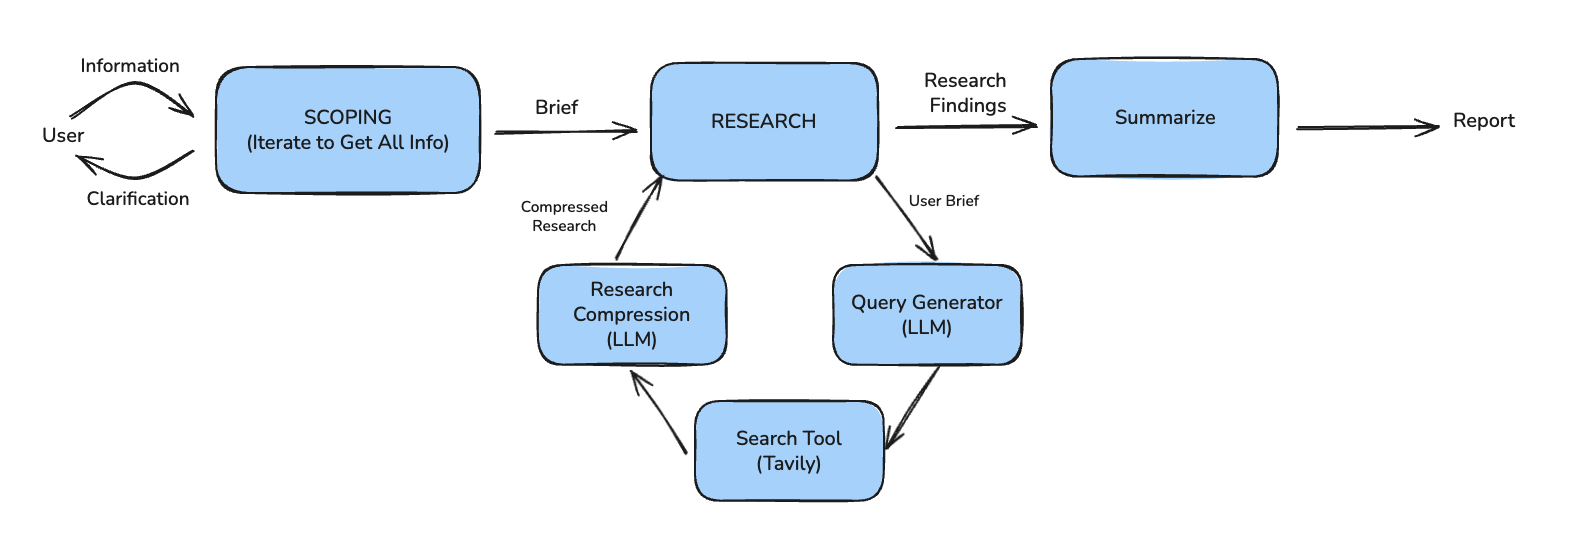

In [1]:
from IPython.display import Image

Image("../images/single_tool_call.png")

Once we have a clearly scoped the problem, the next stage is `Research`.

`Research` involves possible stages:
1. Generate Queries 
2. Search the web 
3. Reflect on the information you obtained and any new research areas
4. Repeating steps 1-3 as needed

## Imports

In [2]:
import sys 
sys.path.insert(0,"../code")

In [3]:
from utils_import import *
import utils_display
from utils_import import *
import prompts
import rich
import utils

from textwrap import dedent
from langchain_openai import ChatOpenAI


import operator
from typing import List, Optional, Sequence

from langchain_core.messages import BaseMessage
from pydantic import BaseModel, Field
from typing_extensions import Annotated, Literal


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



## Structued Output

In [4]:
class QueryPlanOutput(BaseModel):
    """Queries to explore in this research step."""

    queries: List[str] = Field(..., min_length=1, max_length=3)
    rationale: str


class ReflectionDecisionOutput(BaseModel):
    """Decision emitted by the reflection step."""

    analysis: str = Field("analyis of our current research progress")
    next_step: Literal["followup", "final"]
    followup_focus: str = Field("possible areas of followup research")

In [5]:
class AgentState(BaseModel):
    """State container for the planner-driven research workflow."""

    # research brief from the scoping step
    research_brief: str

    messages: Annotated[Sequence[BaseMessage], operator.add] = []
    
    notes:str = ""

    # how many web searches were made 
    tool_call_iterations: int = 0
    max_tool_calls: int = 30

    # all the queries we performed searches for 
    all_queries: Annotated[List[str], operator.add] = []
    
    # queries that were performed in the latest tool call iteration
    latest_queries: Optional[List[str]] = None


    # all raw notes from the web search step
    all_raw_notes: Annotated[List[str], operator.add] = Field(default_factory=list)
    latest_raw_notes:  Optional[List[str]] = None

    # decision from the latest reflection step
    latest_reflection_decision: Optional[ReflectionDecisionOutput] = None


### Web Search

We will be using Tavily to search the web. 

For certain websites Tavily, provides us the raw content of the page.
If the raw content is provided, we will make an llm call to summarize the page.



In [ ]:
model = ChatOpenAI(
        model=OPENAI_MODEL,
        base_url=OPENAI_BASE_URL,
        api_key=OPENAI_API_KEY,
        temperature=0.0,
        #max_tokens=512,
)

In [7]:
query = 'best coffee shops in Seattle with amazing ambiance 2025'      

simple code to make a call to Tavily to search the web and get raw content from pages

In [8]:
%psource utils.tavily_search


def tavily_search(query:str, max_results: int = 3, include_raw_content=True, topic: str = "general", **kw):
    tavily_api_key = os.environ.get("TAVILY_API_KEY")
    if tavily_api_key is None:
        r = requests.post(constants.TAVILY_BASE_URL,
                        json={"query": query, "max_results": max_results, "include_raw_content": include_raw_content, "topic": topic, **kw}, timeout=60)
        r.raise_for_status()
        return r.json()
    else:
        tavily_client = TavilyClient(api_key=tavily_api_key)

        return tavily_client.search(
            query=query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic,
            **kw
        )


`utils.web_search` searches Tavily and then summarizes the web page content

In [9]:
%psource utils.web_search


def web_search(query: str, max_results: int = 3) -> str:
    """Search the web for information about a specific query.
    
    Args:
        query: The search query (be specific for better results)
        max_results: Number of results to return (1-5)
        
    Returns:
        Formatted search results with sources
    """
    print(f"🔍 Searching: {query}")
    
    result = tavily_search(
        query,
        max_results=max_results,
        include_raw_content=True,
        topic="general"
    )
    
    unique_results = {}
    for res in result.get('results', []):
        url = res.get('url')
        if not url or url in unique_results:
            continue

        raw_content = res.get('raw_content')
        fallback_content = res.get('content') or ""
        content = summarize_webpage_content(raw_content or fallback_content)

        unique_results[url] = {
            'title': res.get('title', 'Untitled Source'),
            'content': content
        }
    
    if not u

In [10]:
%psource utils.summarize_webpage_content


def summarize_webpage_content(webpage_content:str) -> str:
    """Summarize webpage content."""
    if not webpage_content:
        return "No content available from this source."

    if not isinstance(webpage_content, str):
        webpage_content = str(webpage_content)


    try:
        summarization_model = ChatOpenAI(
            model="gpt-4o-mini",
            base_url=constants.OPENAI_BASE_URL,
        ).with_structured_output(schema.SummaryOutput)


        system_prompt = prompts.summarize_webpage.format(date=utils.get_today_str(), webpage_content=webpage_content)


        summary = summarization_model.invoke([
            HumanMessage(content=system_prompt)
        ])

        return (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
    except Exception as e:
        print(f"Summarization failed: {e}")
        trimmed = webpage_content if len(webpage_content) <= 1000 else webpage_c

`utils.summarize_webpage_content` is a thin wrapper around a summarization llm call

In [11]:
utils_display.show_prompt(prompts.summarize_webpage, "Summarize Prompt")

╭─────────────────────────────────────────────── Summarize Prompt ────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  You are an expert at summarizing the web content retrieved from the web search.You are tasked with             │
│  summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that    │
│  preserves the important information from the original web page. This summary will be used by a downstream      │
│  research agent, so it's crucial to maintain the key details without losing essential information.              │
│                                                                                                                 │
│  Here is the raw content of the webpage:                                                                        │
│                                                                                                                 │
│  <webpage_content>                                                                                              │
│  {webpage_content}                                                                                              │
│  </webpage_content>                                                                                             │
│                                                                                                                 │
│  Please follow these guidelines to create your summary:                                                         │
│                                                                                                                 │
│  1. Identify and preserve the main topic or purpose of the webpage.                                             │
│  2. Retain key facts, statistics, and data points that are central to the content's message.                    │
│  3. Keep important quotes from credible sources or experts.                                                     │
│  4. Maintain the chronological order of events if the content is time-sensitive or historical.                  │
│  5. Preserve any lists or step-by-step instructions if present.                                                 │
│  6. Include relevant dates, names, and locations that are crucial to understanding the content.                 │
│  7. Summarize lengthy explanations while keeping the core message intact.                                       │
│                                                                                                                 │
│  When handling different types of content:                                                                      │
│                                                                                                                 │
│  - For news articles: Focus on the who, what, when, where, why, and how.                                        │
│  - For scientific content: Preserve methodology, results, and conclusions.                                      │
│  - For opinion pieces: Maintain the main arguments and supporting points.                                       │
│  - For product pages: Keep key features, specifications, and unique selling points.                             │
│                                                                                                                 │
│  Your summary should be significantly shorter than the original content but comprehensive enough to stand       │
│  alone as a source of information.                                                                              │
│                                                                                                                 │
│  Remember, your goal is to create a summary that can b

## Web Search in action

In [12]:
query = 'best coffee shops in Seattle with amazing ambiance 2025'      

In [13]:
search_results  = utils.tavily_search(query)
rich.print(search_results)

{
    'query': 'best coffee shops in Seattle with amazing ambiance 2025',
    'follow_up_questions': None,
    'answer': None,
    'images': [],
    'results': [
        {
            'title': 'Seattle Coffee Shops 2025 | TikTok',
            'url': 'https://www.tiktok.com/discover/seattle-coffee-shops-2025',
            'content': 'Explore the best coffee shops in Seattle for 2025 ! Discover unique cafes like Aroom Coffee
and Pike Place Coffee .',
            'score': 0.8747745,
            'raw_content': None
        },
        {
            'title': "Seattle 's Best Brunch [Updated 2025 ]",
            'url': 'https://seattlesecrets.org/best-brunch-in-seattle',
            'content': "If you're in Seattle and looking for a brunch spot that combines excellent food with an 
inviting ambiance , Finch & Pine is where you want to be. Trust me, your taste buds will thank you!. You might also
want to check out the best coffee shop",
            'score': 0.8312667,
            'raw_content': '![logo](/images/logo/logo-seattle.webp)\n\n# Best Brunch in Seattle: Complete Guide 
(2025)\n\n![Jay Inslee](/images/author/author-seattle.webp)\n![Best Brunch in Seattle: Complete Guide 
(2025)](/images/posts/b/brunch-seattle.webp)\n![Food tour 
map](/_next/static/media/map-with-points.eafe12a0.webp)\n\n## The 48-Hour Insider Itinerary to Seattle\n\nJoin our 
Seattle Secrets newsletter and get our 48-hour insider itinerary to the top hidden spots in Seattle.\n\nWith 
countless mornings spent savoring fluffy pancakes and perfectly brewed coffee, I’ve explored every nook and cranny 
of this vibrant city, discovering hidden gems and beloved classics alike. After reviewing 13 top locations, I’ve 
compiled a list that not only highlights mouthwatering dishes but also captures the unique atmosphere that makes 
each spot special.\n\nYou might wonder why you should trust my taste buds. Well, let’s just say I’ve tasted enough 
avocado toast to know what makes it truly great! Whether you’re a local looking for your new weekend haunt or a 
visitor eager to dive into Seattle’s brunch scene, I promise you’ll find something here to tickle your taste buds 
and warm your heart.\n\n## 
Nue\n\n![Nue](https://lh5.googleusercontent.com/p/AF1QipMh1gvmqjLjW5aaYL3m13ORicUFwm5pfKR-Js81=w1220-h920-k-no)\n\n
| Highlights |\n| --- |\n| Great vibes, cool clientele |\n| Unique flavor combinations |\n| Devine coffee |\n| 
Friendly and knowledgeable staff |\n| Must-visit brunch spot |\n\nNue in Seattle is an absolute gem that makes 
brunch an art form! From the moment I stepped in, I was enveloped by its **great vibes** and an eclectic mix of 
cool clientele. This spot effortlessly combines a laid-back ambiance with a dash of creativity.\n\nThe menu at Nue 
is a delightful tapestry of **unique flavor combinations** that dance on your palate. I couldn\'t resist trying 
their signature dishes, and let me tell you, they exceeded all my expectations! Each bite was a wonderful surprise,
weaving together exciting tastes that are hard to find elsewhere.\n\nAnd can we talk about the coffee? It was 
simply **divine**—rich and robust, elevating my brunch experience to new heights. The staff here are truly a 
treasure, being both **friendly** and extremely knowledgeable about the menu. They’re always eager to offer their 
recommendations, ensuring you enjoy your meal to the fullest.\n\nIf you’re on the hunt for a **must-visit brunch 
spot**, look no further than Nue. It’s lively, delicious, and ultimately satisfying—a triumphant celebration of 
what brunch should truly be! 🥂✨\n\nYou might also want to check out the  [best french toast in 
Seattle](/best-french-toast-in-seattle).\n\n## Portage Bay Cafe - South Lake Union\n\n![Portage Bay Cafe - South 
Lake Union](https://lh5.googleusercontent.com/p/AF1QipNXzyLM8qlbPhejUjt9nad-2OD_kXWDEKQgJOil=w1220-h920-k-no)\n\n| 
Highlights |\n| --- |\n| ***Vibrant ambience and crowd*** |\n| ***Delicious pancakes and toasts*** |\n| 
***Impressive qu

In [14]:
raw_content_webpage = search_results['results'][1]['raw_content']

summarized_webpage = utils.summarize_webpage_content(raw_content_webpage)

rich.print(raw_content_webpage)
rich.print(summarized_webpage)

!(/images/logo/logo-seattle.webp)

# Best Brunch in Seattle: Complete Guide (2025)

![Jay Inslee](/images/author/author-seattle.webp)
![Best Brunch in Seattle: Complete Guide (2025)](/images/posts/b/brunch-seattle.webp)
![Food tour map](/_next/static/media/map-with-points.eafe12a0.webp)

## The 48-Hour Insider Itinerary to Seattle

Join our Seattle Secrets newsletter and get our 48-hour insider itinerary to the top hidden spots in Seattle.

With countless mornings spent savoring fluffy pancakes and perfectly brewed coffee, I’ve explored every nook and 
cranny of this vibrant city, discovering hidden gems and beloved classics alike. After reviewing 13 top locations, 
I’ve compiled a list that not only highlights mouthwatering dishes but also captures the unique atmosphere that 
makes each spot special.

You might wonder why you should trust my taste buds. Well, let’s just say I’ve tasted enough avocado toast to know 
what makes it truly great! Whether you’re a local looking for your new weekend haunt or a visitor eager to dive 
into Seattle’s brunch scene, I promise you’ll find something here to tickle your taste buds and warm your heart.

## Nue

![Nue](https://lh5.googleusercontent.com/p/AF1QipMh1gvmqjLjW5aaYL3m13ORicUFwm5pfKR-Js81=w1220-h920-k-no)

| Highlights |
| --- |
| Great vibes, cool clientele |
| Unique flavor combinations |
| Devine coffee |
| Friendly and knowledgeable staff |
| Must-visit brunch spot |

Nue in Seattle is an absolute gem that makes brunch an art form! From the moment I stepped in, I was enveloped by 
its **great vibes** and an eclectic mix of cool clientele. This spot effortlessly combines a laid-back ambiance 
with a dash of creativity.

The menu at Nue is a delightful tapestry of **unique flavor combinations** that dance on your palate. I couldn't 
resist trying their signature dishes, and let me tell you, they exceeded all my expectations! Each bite was a 
wonderful surprise, weaving together exciting tastes that are hard to find elsewhere.

And can we talk about the coffee? It was simply **divine**—rich and robust, elevating my brunch experience to new 
heights. The staff here are truly a treasure, being both **friendly** and extremely knowledgeable about the menu. 
They’re always eager to offer their recommendations, ensuring you enjoy your meal to the fullest.

If you’re on the hunt for a **must-visit brunch spot**, look no further than Nue. It’s lively, delicious, and 
ultimately satisfying—a triumphant celebration of what brunch should truly be! 🥂✨

You might also want to check out the  (/best-french-toast-in-seattle).

## Portage Bay Cafe - South Lake Union

![Portage Bay Cafe - South Lake 
Union](https://lh5.googleusercontent.com/p/AF1QipNXzyLM8qlbPhejUjt9nad-2OD_kXWDEKQgJOil=w1220-h920-k-no)

| Highlights |
| --- |
| ***Vibrant ambience and crowd*** |
| ***Delicious pancakes and toasts*** |
| ***Impressive quality of food*** |
| ***Top-notch customer service*** |
| ***Engaging and attentive staff*** |

Portage Bay Cafe - South Lake Union is a delightful haven for brunch enthusiasts seeking both flavor and fun. As I 
stepped inside, the ***vibrant ambience*** enveloped me, bustling with cheerful chatter and the enticing aroma of 
freshly prepared dishes. One cannot help but be drawn in by the atmosphere that feels both lively and inviting.

Now, let’s talk about the food. I savored a stack of their ***delicious pancakes***, which were perfectly fluffy 
and tantalizingly topped with seasonal berries. Each bite felt like a sweet embrace. The ***quality of the food*** 
is truly impressive, highlighting local ingredients and innovative recipes that elevate the brunch experience.

What truly set this spot apart, however, was the ***top-notch customer service***. The staff was not only engaging 
but incredibly attentive, ensuring my coffee cup was always full while providing genuine recommendations from the 
menu. I appreciated their enthusiasm and expertise when discussing the various ***toast

<summary>
This comprehensive guide explores the best brunch spots in Seattle for 2025, featuring 13 notable restaurants that 
offer unique dining experiences. Each establishment is reviewed for its ambiance, menu highlights, customer 
service, and overall atmosphere, making it suitable for both locals and visitors. Prominent recommendations include
Nue for its unique flavors and divine coffee, Portage Bay Cafe for its vibrant ambiance and delicious pancakes, and
Finch & Pine, known for its cozy atmosphere and mochi muffins. Harry's Beach House offers beachside dining with 
unique menu options, while places like Oddfellows Café serve excellent mochas but have mixed reviews on food 
quality. Other noteworthy spots include Le Coin for French cuisine, Arthur's with its expansive menu and trendy 
decor, and Tilikum Place Cafe known for its Dutch Babies. Overall, the guide captures the essence of Seattle’s 
diverse brunch culture, highlighting not only the food but also the welcoming environments that define each 
location.
</summary>

<key_excerpts>
- **Nue**: Unique flavor combinations, great coffee, must-visit brunch spot.
- **Portage Bay Cafe**: Delicious pancakes, vibrant ambience, impressive quality of food.
- **Finch & Pine**: Cozy atmosphere, delicious mochi muffin, creative brunch dishes.
- **Harry's Beach House**: Beachside dining, unique menu, big portions.
- **Oddfellows Café**: Nice environment, excellent mocha, average food quality.
- **Le Coin**: French-style ambiance, excellent made-to-order food, solid cocktail selection.
- **Tilikum Place Cafe**: Unique Dutch Baby creations, family-friendly atmosphere.
- **Lola**: Incredible Eggs Benedict, cozy dining experience.
</key_excerpts>

In [15]:
web_search_result = utils.web_search(query, max_results=3)


rich.print(web_search_result)

🔍 Searching: best coffee shops in Seattle with amazing ambiance 2025


Search results for: 'best coffee shops in Seattle with amazing ambiance 2025'


--- SOURCE 1: Seattle Coffee Shops 2025 | TikTok ---
URL: https://www.tiktok.com/discover/seattle-coffee-shops-2025

<summary>
This webpage highlights the best coffee shops in Seattle for 2025, showcasing unique cafes such as Aroom Coffee and
Pike Place Coffee.
</summary>

<key_excerpts>
"Explore the best coffee shops in Seattle for 2025! Discover unique cafes like Aroom Coffee and Pike Place Coffee."
</key_excerpts>

--------------------------------------------------------------------------------

--- SOURCE 2: Seattle 's Best Brunch [Updated 2025 ] ---
URL: https://seattlesecrets.org/best-brunch-in-seattle

<summary>
This comprehensive guide explores the best brunch spots in Seattle for 2025, featuring 13 notable restaurants that 
offer unique dining experiences. Each establishment is reviewed for its ambiance, menu highlights, customer 
service, and overall atmosphere, making it suitable for both locals and visitors. Prominent recommendations include
Nue for its unique flavors and divine coffee, Portage Bay Cafe for its vibrant ambiance and delicious pancakes, and
Finch & Pine, known for its cozy atmosphere and mochi muffins. Harry's Beach House offers beachside dining with 
unique menu options, while places like Oddfellows Café serve excellent mochas but have mixed reviews on food 
quality. Other noteworthy spots include Le Coin for French cuisine, Arthur's with its expansive menu and trendy 
decor, and Tilikum Place Cafe known for its Dutch Babies. Overall, the guide captures the essence of Seattle’s 
diverse brunch culture, highlighting not only the food but also the welcoming environments that define each 
location.
</summary>

<key_excerpts>
- **Nue**: Unique flavor combinations, great coffee, must-visit brunch spot.
- **Portage Bay Cafe**: Delicious pancakes, vibrant ambience, impressive quality of food.
- **Finch & Pine**: Cozy atmosphere, delicious mochi muffin, creative brunch dishes.
- **Harry's Beach House**: Beachside dining, unique menu, big portions.
- **Oddfellows Café**: Nice environment, excellent mocha, average food quality.
- **Le Coin**: French-style ambiance, excellent made-to-order food, solid cocktail selection.
- **Tilikum Place Cafe**: Unique Dutch Baby creations, family-friendly atmosphere.
- **Lola**: Incredible Eggs Benedict, cozy dining experience.
</key_excerpts>

--------------------------------------------------------------------------------

--- SOURCE 3: Moore Coffee Shop - Seattle ---
URL: https://us.a-better-place.com/moore-coffee-shop-i1941740.html

<summary>
Moore Coffee Shop, located at 1930 2nd Ave, Seattle, WA 98101, offers a welcoming atmosphere for coffee 
enthusiasts. Open Thursday through Friday from 7:30 AM to 3:30 PM, Saturday from 8:00 AM to 3:30 PM, and Sunday 
from 8:00 AM to 3:00 PM, it has an average rating of 3.5 based on 21 reviews. For more details, the shop can be 
reached at (206) 883-7044. It is also associated with related searches for other coffee spots and amenities in the 
Seattle area.
</summary>

<key_excerpts>
**Address:** 1930 2nd Ave , Seattle 98101, WA, US
**Phone:** (206) 883-7044
**Opening Hours:** Thursday: 07:30-15:30, Friday: 07:30-15:30, Saturday: 08:00-15:30, Sunday: 08:00-15:00
**Average Rating:** 3.5 from 21 votes.
</key_excerpts>

--------------------------------------------------------------------------------

## Workflow nodes

We have four nodes corresponding  to four steps in our research flow:
- generate_queries
- search_web
- reflect_and_decide
- compress_research

In [16]:
from langchain_core.messages import HumanMessage, AIMessage



def generate_queries(state: AgentState) -> AgentState:
    """Node 1: Generate possible queries to execute."""


    latest_reflection_str =  "No recent reflections."
    previous_queries_str=""

    if state.all_queries:
        previous_queries_str = "\n".join(
            [f"- {q}" for q in state.all_queries]
        )

    if state.latest_reflection_decision:
        latest_reflection_str = (
            f"Analysis: {state.latest_reflection_decision.analysis}\n"
            f"Prior next step: {state.latest_reflection_decision.next_step}\n"
            f"Suggested focus: {state.latest_reflection_decision.followup_focus or 'None'}"
        )

    QUERY_PLANNER_SYSTEM_PROMPT = dedent(
        """
        You are a research query planner. Today's date is {date}.

        Craft up to three specific web search queries that will advance the research task.
        
        Use recent reflections and search query history to avoid duplicate effort, fill knowledge gaps,
        and stay focused on the user's request.

        The search queries should be specific and targeted to gather relevant information and should have all the context needed to perform a web search.

        <Research Context>
        {research_brief}
        </Research Context>

        <Search Query History>
        {search_query_history}
        </Search Query History>
        
        <Recent Reflections>
        {recent_reflections}        
        </Recent Reflections>

        """
    )


    prompt = QUERY_PLANNER_SYSTEM_PROMPT.format(date=utils.get_today_str(), 
                                                research_brief=state.research_brief ,
                                                search_query_history=previous_queries_str,
                                                recent_reflections=latest_reflection_str
                                               )


    model_queries = model.with_structured_output(QueryPlanOutput)
    plan = model_queries.invoke( [ HumanMessage(content=prompt) ])


    return {
        "latest_queries": plan.queries,
        "messages": [AIMessage(content=f"Generated Query Plan: {plan.queries}\nRationale: {plan.rationale}")]
    }


def search_web(state: AgentState) -> AgentState:
    """Node 2: execute Tavily searches for the planned queries."""



    raw_notes: List[str] = []

    messages = []
    queries = []
    for query in state.latest_queries:
        note = utils.web_search(query=query)
        raw_notes.append(note)

        queries.append(query)
        messages.append(AIMessage(content=f"search_web: {query}\n{note}"))


    return {
        "tool_call_iterations": state.tool_call_iterations + len(raw_notes),
        "messages": messages,
        
        "all_queries": queries, # appends to list of all queries
        "latest_queries": queries, # only stores latest queries
        
        "latest_raw_notes": raw_notes, # only stores latest raw notes
        "all_raw_notes": raw_notes,  # appends to list of all notes
    }




def reflect_and_decide(state: AgentState) -> AgentState:
    """Node 3: reflect on findings and return next step."""


    latest_notes_str = ""

    if state.latest_raw_notes:
        latest_notes_str = "\n\n".join(state.latest_raw_notes)


    REFLECTION_SYSTEM_PROMPT = dedent(
        """
        You are a world class researcher. Today's date is {date}.

        You are given a research brief, and  all your research notes from web searches.

        Evaluate the latest Web search notes to decide the next action.
        Provide structured output with:
        - analysis: detailed synthesis of findings (cite sources inline)
        - next_step: "followup" to continue researching or "final" to conclude
        - followup_focus: guidance for the next query plan when continuing
        - final_response: if concluding, the full answer for the user

        <Research Context>
        {research_brief}
        </Research Context>

        <Latest Web Search Notes>
        {latest_notes}
        </Latest Web Search Notes>

        <Search Query History>
        {search_query_history}
        </Search Query History>

        """
    )
    prompt = REFLECTION_SYSTEM_PROMPT.format(
        date=utils.get_today_str()
        , research_brief=state.research_brief
        , latest_notes=latest_notes_str
        , search_query_history="\n".join(
            [f"- {q}" for q in state.all_queries]
        )
    )



    messages = [HumanMessage(content=prompt)]

    model_reflection = model.with_structured_output(ReflectionDecisionOutput)

    decision:ReflectionDecisionOutput = model_reflection.invoke(messages)

    

    print(f"💭 Thinking: {decision.followup_focus[:100]}...")
    return {
        "latest_raw_notes": None,
        "latest_queries": None,
        "latest_reflection_decision": decision,
        "messages": [AIMessage(content=f"Reflection Decision: {decision}")]
    }


def compress_research(state: AgentState) -> AgentState:
    """Compress research findings while maintaining source fidelity."""

    notes = "\n".join(state.all_raw_notes)
    return {
        "notes": notes
    }



def next_step_after_reflection(state: AgentState) -> Literal["generate_queries", "compress_research"]:
    """
    After the reflection step, decide the next node to execute.

    We either go back to generating more queries or compress the research findings.
    """

    decision = state.latest_reflection_decision


    if state.tool_call_iterations > state.max_tool_calls:
        return "compress_research"

    if decision.next_step == "followup" :
        return "generate_queries"

    if decision.next_step == "final":
        return "compress_research"





## Graph

In [17]:
from langgraph.graph import StateGraph, START, END

agent_builder = StateGraph(AgentState)

agent_builder.add_node("generate_queries", generate_queries)
agent_builder.add_node("search_web", search_web)
agent_builder.add_node("reflect", reflect_and_decide)
agent_builder.add_node("compress_research", compress_research)

agent_builder.add_edge(START, "generate_queries")
agent_builder.add_edge("generate_queries", "search_web")
agent_builder.add_edge("search_web", "reflect")
agent_builder.add_conditional_edges(
    "reflect",
    next_step_after_reflection,
    {
        "generate_queries": "generate_queries",
        "compress_research": "compress_research",
    },
)
agent_builder.add_edge("compress_research", END)

researcher_agent = agent_builder.compile()

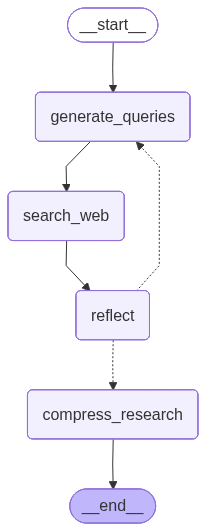

In [18]:
from IPython.display import Image, display

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

## Graph Execution

In [19]:

research_brief ="""I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. 
My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,
including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences
regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these
should be considered flexible unless they are relevant to ambiance. Please prioritize information from official
coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local
publications. The research should be current as of October 2025."""



with tracer.start_as_current_span("research_workflow"):
    result = researcher_agent.invoke({"research_brief": research_brief})

🔍 Searching: best Seattle coffee shops for ambiance 2025 site:seattlemag.com OR site:seattlemet.com OR site:thestranger.com
🔍 Searching: Seattle coffee shops with unique interior design and atmosphere 2025 reviews site:yelp.com OR site:tripadvisor.com
🔍 Searching: top Seattle coffee shops ambiance official websites 2025
💭 Thinking: N/A...


We see that initially the LLM made three broad search query.  

It then identified three coffee shops to dive deeper 


In [20]:
utils_display.format_messages(result['messages'])

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Generated Query Plan: ['best Seattle coffee shops for ambiance 2025 site:seattlemag.com OR site:seattlemet.com  │
│ OR site:thestranger.com', 'Seattle coffee shops with unique interior design and atmosphere 2025 reviews         │
│ site:yelp.com OR site:tripadvisor.com', 'top Seattle coffee shops ambiance official websites 2025']             │
│ Rationale: These queries are designed to gather up-to-date and detailed information about Seattle coffee shops  │
│ with a focus on ambiance. The first query targets recent curated lists and articles from reputable local        │
│ publications, which often highlight ambiance as a key factor. The second query focuses on user-generated        │
│ reviews from major platforms, filtering for recent opinions specifically about interior design and atmosphere.  │
│ The third query aims to find information directly from official coffee shop websites, which may showcase their  │
│ ambiance through photos and descriptions. This approach ensures a comprehensive and current overview from       │
│ multiple credible sources.                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ search_web: best Seattle coffee shops for ambiance 2025 site:seattlemag.com OR site:seattlemet.com OR           │
│ site:thestranger.com                                                                                            │
│ Search results for: 'best Seattle coffee shops for ambiance 2025 site:seattlemag.com OR site:seattlemet.com OR  │
│ site:thestranger.com'                                                                                           │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: The Best Coffee Shops in Seattle ---                                                              │
│ URL: https://www.seattlemet.com/eat-and-drink/best-coffee-shops-in-seattle-washington                           │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ This guide from Seattle Met details noteworthy coffee shops in Seattle, categorized into segments such as       │
│ "Coffee Centric", "Community Hubs", and "Pioneers". Each section highlights several shops, emphasizing unique   │
│ brewing methods, community involvement, and historical significance in the city's coffee culture. For example,  │
│ Analog in Capitol Hill is praised for its consistency and atmosphere, while Phin in Little Saigon focuses on    │
│ traditional Vietnamese brewing. Notable community spots include The Station for its neighborhood events and Mr. │
│ West for its all-day café offerings. Pioneers like Caffe Vita and Espresso Vivace showcase Seattle's coffee     │
│ legacy, contributing to the city's rich coffee scene that appeals to both aficionados and casual drinkers       │
│ alike.                                                                                                          │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ 1. "Seattle’s coffee culture is vibrant and diverse, with coffee shops catering to different needs—community,   │
│ craft, and creativity."                                                                                         │
│ 2. "Analog Coffee has a meticulously crafted coffee program, appealing to both casual drinkers and              │
│ connoisseurs."                                                                                                  │
│ 3. "The Station exemplifies a 'third place' atmosphere, engaging the community with events and supporting local │
│ artists."                                                                                                       │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│ --- SOURCE 2: Best Coffee Shop: Anchorhead Coffee ---                                                           │
│ URL: https://seattlemag.com/food-drink/best-coffee-shop-2024/                                                   │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ search_web: Seattle coffee shops with unique interior design and atmosphere 2025 reviews site:yelp.com OR       │
│ site:tripadvisor.com                                                                                            │
│ Search results for: 'Seattle coffee shops with unique interior design and atmosphere 2025 reviews site:yelp.com │
│ OR site:tripadvisor.com'                                                                                        │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: TOP 10 BEST Aesthetic Cafe in Seattle, WA - Updated 2025 ---                                      │
│ URL: https://www.yelp.com/search?find_desc=Aesthetic+Cafe&find_loc=Seattle%2C+WA                                │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ The webpage lists the top 10 aesthetic cafes in Seattle, WA, as updated in October 2025, featuring notable      │
│ places such as Santo Coffee, Café Hagen, Phe, Koto Jelly Coffee, and Cafe An'Clair. These cafes are recognized  │
│ for their unique ambiance and appeal, making them popular choices for visitors and locals alike.                │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ Top 10 Best Aesthetic Cafe in Seattle, WA - Last Updated October 2025 - Yelp.                                   │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│ --- SOURCE 2: STORYVILLE COFFEE COMPANY - Seattle, Washington ---                                               │
│ URL:                                                                                                            │
│ https://www.yelp.com/biz/storyville-coffee-company-seattle-9?adjust_creative=mapquest&start=1340&utm_campaign=y │
│ elp_feed&utm_medium=feed_v2&utm_source=mapquest                                                                 │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ Storyville is a coffee shop located on the 2nd floor near Pike Place Market, which is hard to find but highly   │
│ recommended for coffee seekers.                                                                                 │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ "I found Storyville on Yelp when we needed coffee before walking around Pike Place Market..."                   │
│ </key_excerpts>                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ search_web: top Seattle coffee shops ambiance official websites 2025                                            │
│ Search results for: 'top Seattle coffee shops ambiance official websites 2025'                                  │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: TOP 10 BEST Coffee Meeting in Seattle, WA - Updated 2025 - Yelp ---                               │
│ URL: https://www.yelp.com/search?find_desc=Coffee+Meeting&find_loc=Seattle%2C+WA                                │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ This webpage lists several coffee shops and cafes, including: 1. Basecamp Cafe 2. Anchorhead Coffee -           │
│ CenturyLink Plaza 3. Armistice Coffee Roaster 4. Olympia Coffee 5. Fuel Coffee & Books 6. Bonito Cafe y         │
│ Mercadito.                                                                                                      │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ List of coffee shops: Basecamp Cafe, Anchorhead Coffee - CenturyLink Plaza, Armistice Coffee Roaster, Olympia   │
│ Coffee, Fuel Coffee & Books, Bonito Cafe y Mercadito.                                                           │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│ --- SOURCE 2: 15 Best Cafes & Coffee Shops in Seattle's Capitol Hill (2025 Guide) ---                           │
│ URL: https://www.emmasedition.com/2025/09/15-best-cafes-coffee-shops-in-seattles-capitol-hill-2025-guide.html   │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ This webpage offers a comprehensive guide to the 15 best cafes and coffee shops in Seattle's Capitol Hill       │
│ neighborhood as of 2025. It features a diverse range of establishments, highlighting unique offerings such as   │
│ Latinx-inspired drinks at Bonito Cafe Y Mercadito, a cafe by day and cocktail bar by night at Laurel, and a     │
│ French-inspired bakery at The French Guys Bakery. Other highlights include Wunderground Cafe, known for         │
│ mushroom coffee, and Starbucks Roastery, which features an extensive menu distinct from regular Starbucks       │
│ locations. There are also mentions of cafes in adjacent neighborhoods, such as URL Coffee and The Usual,        │
│ enhancing the guide's utility for coffee lovers exploring the area.                                             │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                         

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Reflection Decision: analysis="The latest web search notes provide a comprehensive and up-to-date overview of   │
│ Seattle's best coffee shops with a focus on ambiance, drawing from reputable local publications (Seattle Met,   │
│ Seattle Magazine), review platforms (Yelp), and curated guides. Several coffee shops are repeatedly highlighted │
│ for their unique atmosphere and interior design, such as Analog Coffee (praised for its crafted program and     │
│ vibe), Anchorhead Coffee (noted for its relaxed yet serious atmosphere), and Storyville Coffee Company          │
│ (recommended for its hidden, cozy location near Pike Place Market). Yelp's 2025 lists add further detail,       │
│ naming Santo Coffee, Café Hagen, Phe, Koto Jelly Coffee, and Cafe An'Clair as top aesthetic cafes, and          │
│ providing additional options like Olympia Coffee, Armistice Coffee Roaster, and Bonito Cafe y Mercadito. The    │
│ Capitol Hill neighborhood emerges as a hotspot for unique and vibrant coffee shop experiences, with venues like │
│ Laurel (cafe by day, cocktail bar by night), Wunderground Cafe (mushroom coffee), and the Starbucks Roastery    │
│ (distinctive menu and mixology bar). The sources collectively emphasize ambiance factors such as interior       │
│ design, comfort, community engagement, and overall vibe, aligning well with the research goal. There is now     │
│ sufficient, current, and diverse information to synthesize a final comparative answer." next_step='final'       │
│ followup_focus='N/A'                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [21]:
from rich.markdown import Markdown
Markdown(result['notes'])

Search results for: 'best Seattle coffee shops for ambiance 2025 site:seattlemag.com OR site:seattlemet.com OR     
site:thestranger.com'                                                                                              

--- SOURCE 1: The Best Coffee Shops in Seattle --- URL:                                                            
https://www.seattlemet.com/eat-and-drink/best-coffee-shops-in-seattle-washington                                   


<key_excerpts>                                                                                                     

 1 "Seattle’s coffee culture is vibrant and diverse, with coffee shops catering to different needs—community,      
   craft, and creativity."                                                                                         
 2 "Analog Coffee has a meticulously crafted coffee program, appealing to both casual drinkers and connoisseurs."  
 3 "The Station exemplifies a 'third place' atmosphere, engaging the community with events and supporting local    
   artists." </key_excerpts>                                                                                       

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
--- SOURCE 2: Best Coffee Shop: Anchorhead Coffee --- URL: https://seattlemag.com/food-drink/best-coffee-shop-2024/


<key_excerpts> "Best Coffee Shop: Anchorhead Coffee"                                                               
"The atmosphere is relaxed, but the coffee is serious."                                                            
"Sign up for a subscription and you’ll never run out of beans. First bag’s always on the house."                   
"Seattle’s halal dining scene is evolving and each plate tells part of the story."                                 
"Join The Must List: Don't miss a thing. Get Seattle's best events, handpicked and delivered to your inbox weekly."
</key_excerpts>                                                                                                    

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
--- SOURCE 3: The U District Hums With Energy --- URL:                                                             
https://seattlemag.com/seattle-culture/the-u-district-hums-with-energy/                                            


Cafes like Café Solstice and Café Allegro serve as popular student hangouts, offering coffee and pastries in a     
welcoming environment. The Ave is a hub for affordable Asian cuisine, while the newly renovated Burke Museum       
showcases extensive paleontological and cultural exhibits. The Henry Art Museum focuses on contemporary art, and   
Grand Illusion cinema screens foreign and indie films. The U District's rich cultural scene also includes the UW   
Drama Department's productions and the scenic 700-acre campus itself, which offers beautiful views and historical  
architecture. The neighborhood promises a rich experience for repeat visitors as it continues to evolve.           


<key_excerpts>                                                                                                     

 • "The neighborhood centered around the University of Washington is one of the city’s most vibrant and eclectic." 
 • "The Burke Museum of Natural History and Culture presents exhibits on Pacific Rim cultures, human evolution, and
   art."                                                                                                           
 • "The University of Washington is a major research institution, ranked No. 7 in the world in the US News and     
   World Report 2024-25 Best Global University Rankings." </key_excerpts>                                          

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Search results for: 'Seattle coffee shops 